# Extract text (Uno only)

With this notebook we extract only dialogues from pages that likely contain Uno.

In [1]:
model_name = 'gemini-2.5-flash-preview-04-17'
thinking_budget = 1024

## Compute contiguous dialogues

In [8]:
import glob
import re

pages_analysis = glob.glob(
    '../output/filtered-pages/gemini-2.5-flash-preview-04-17-bd430ff0/*.json')
pages_analysis.sort(key=lambda x: float(
    re.search(r'pkna-([0-9-]+)', x).group(1).replace('-', '.')))
pages_analysis[:20]

['../output/filtered-pages/gemini-2.5-flash-preview-04-17-bd430ff0/pkna-0.json',
 '../output/filtered-pages/gemini-2.5-flash-preview-04-17-bd430ff0/pkna-0-2.json',
 '../output/filtered-pages/gemini-2.5-flash-preview-04-17-bd430ff0/pkna-0-3.json',
 '../output/filtered-pages/gemini-2.5-flash-preview-04-17-bd430ff0/pkna-1.json',
 '../output/filtered-pages/gemini-2.5-flash-preview-04-17-bd430ff0/pkna-2.json',
 '../output/filtered-pages/gemini-2.5-flash-preview-04-17-bd430ff0/pkna-3.json',
 '../output/filtered-pages/gemini-2.5-flash-preview-04-17-bd430ff0/pkna-4.json',
 '../output/filtered-pages/gemini-2.5-flash-preview-04-17-bd430ff0/pkna-5.json',
 '../output/filtered-pages/gemini-2.5-flash-preview-04-17-bd430ff0/pkna-6.json',
 '../output/filtered-pages/gemini-2.5-flash-preview-04-17-bd430ff0/pkna-7.json',
 '../output/filtered-pages/gemini-2.5-flash-preview-04-17-bd430ff0/pkna-8.json',
 '../output/filtered-pages/gemini-2.5-flash-preview-04-17-bd430ff0/pkna-9.json',
 '../output/filtered-pag

In [34]:
# Apply overrides
import json
import os

overrides_files = glob.glob('../input/overrides/filter/*.json')
filter_overrides = {
    os.path.basename(f): json.load(open(f))
    for f in overrides_files
}

filter_overrides

{'pkna-0.json': {'presence_add': [],
  'presence_remove': ['../input/pkna/pkna-0/pkna-0-004.jpg',
   '../input/pkna/pkna-0/pkna-0-010.jpg',
   '../input/pkna/pkna-0/pkna-0-011.jpg',
   '../input/pkna/pkna-0/pkna-0-017.jpg']}}

In [ ]:
# Apply the overrides to the pages
# TODO

In [35]:
# Parse the JSON files to compute the contiguous pages.
import json

def parse_filter_json(file_path: str) -> list[list[str]]:
    with open(file_path, 'r') as file:
        data = json.load(file)

    presence = set(data['uno_presence'])
    if 'unknown_presence' in data:
        presence.update(data['unknown_presence'])
    # Apply the overrides
    override = filter_overrides.get(os.path.basename(file_path), {})
    for p in override.get('presence_add', []):
        presence.add(p)
    for p in override.get('presence_remove', []):
        presence.discard(p)

    res = []
    curr = []

    for page in data['input_pages']:
        if page in presence:
            curr.append(page)
            continue
        if curr:
            res.append(curr)
            curr = []
    if curr:
        res.append(curr)
    
    return res

parse_filter_json(pages_analysis[0])[:3]

[['../input/pkna/pkna-0/pkna-0-029.jpg',
  '../input/pkna/pkna-0/pkna-0-030.jpg',
  '../input/pkna/pkna-0/pkna-0-031.jpg',
  '../input/pkna/pkna-0/pkna-0-032.jpg',
  '../input/pkna/pkna-0/pkna-0-033.jpg',
  '../input/pkna/pkna-0/pkna-0-034.jpg',
  '../input/pkna/pkna-0/pkna-0-035.jpg',
  '../input/pkna/pkna-0/pkna-0-036.jpg'],
 ['../input/pkna/pkna-0/pkna-0-040.jpg',
  '../input/pkna/pkna-0/pkna-0-041.jpg',
  '../input/pkna/pkna-0/pkna-0-042.jpg',
  '../input/pkna/pkna-0/pkna-0-043.jpg',
  '../input/pkna/pkna-0/pkna-0-044.jpg'],
 ['../input/pkna/pkna-0/pkna-0-046.jpg',
  '../input/pkna/pkna-0/pkna-0-047.jpg',
  '../input/pkna/pkna-0/pkna-0-048.jpg']]

In [36]:
dialogues = []
for file_path in pages_analysis:
    dialogues.extend(parse_filter_json(file_path))

print(f"num dialogues: {len(dialogues)}, num pages: {sum(len(d) for d in dialogues)}")

num dialogues: 471, num pages: 1061


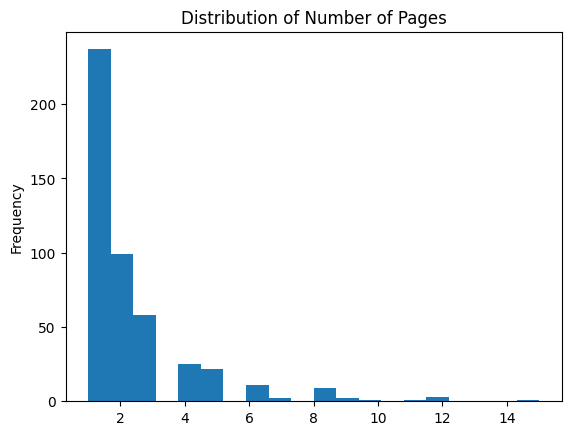

In [38]:
import pandas as pd

# Plot the distribution of the number of pages per dialogue.
df = pd.DataFrame([len(d) for d in dialogues], columns=['num_pages'])
df['num_pages'].plot(kind='hist', bins=20, title='Distribution of Number of Pages');

## Extract dialogues one by one

In [28]:
import os
from google import genai
from dotenv import load_dotenv

load_dotenv()
client = genai.Client(api_key=os.getenv("GEMINI_API_KEY"))

In [39]:
# With structured output.
import json
from dataclasses import dataclass
import PIL.Image
from PIL.Image import Image
from PIL.ImageFile import ImageFile
from google.genai import types
from pydantic import BaseModel, Field


class Bubble(BaseModel):
    character: str = Field(description='Name of the character speaking in the bubble')
    text: str = Field(description='Text of the speech bubble')
    probability: int = Field(description='Probability of the attribution (0-5)')

class Response(BaseModel):
    dialogues: list[Bubble]

@dataclass
class ExtractedDialogue:
    character: str
    text: str
    probability: int


prompt = """You are a comic book dialogue extractor. Given a comic book page image, extract all speech bubbles and assign each one to the character who is speaking. Convert capitalization to normal case. Do not translate the text, report it as is.

If a speaker's name is unclear, try to describe them briefly (e.g., "Masked man", "Woman with red hair").

Only include spoken dialogue from speech bubbles — skip narration boxes, sound effects, or other text. Ensure correct attribution based on visual clues such as tail direction, proximity, character expressions, style of the bubble and overall dialogue context.
Notable characters in this comic are (the list is not exhaustive):
- Paperinik (PK): A superhero alter ego of Donald Duck, known for his intelligence and resourcefulness.
- Donald Duck: The classic Disney character.
- Uno: has a duck-like appearance, inside a sphere that appears to be made of a bright green gelatinous substance, with small bubbles. It has a short, rounded beak, large, black eyes without defined pupils.
- Everett Ducklair: A duck with a large head and brown hair, usually with a serious expression and wearing a robe-like outfit.

For character attribution, also output the probability of the attribution in parentheses, from 0 to 5. Assign points based on the following criteria:
- One point if the character is clearly visible in the image and their name is known.
- One point if the speech bubble tail is pointing to the character.
- One point if the name of the character is known from the context of the dialogue.
- One point if the style of the bubble is consistent within the page.
- One point if the attribution is consistent with the overall dialogue context.

If there are multiple bubbles in the same frame, it's likely that different characters are speaking, even if one is not visible.
"""

def parse_dialogue(image: ImageFile | str) -> list[ExtractedDialogue]:
    if isinstance(image, str):
        image = PIL.Image.open(image)
    # Run the prompt
    response = client.models.generate_content(
        model=model_name,
        config=types.GenerateContentConfig(
            max_output_tokens=65536,
            response_mime_type='application/json',
            response_schema=Response.model_json_schema(),
            thinking_config=types.ThinkingConfig(thinking_budget=thinking_budget),
        ),
        contents=[prompt, image], # type: ignore
    )
    if not response.text:
        raise ValueError("Response is empty")
    # Parse the response
    parsed = json.loads(response.text)
    return [ExtractedDialogue(**bubble) for bubble in parsed['dialogues']]

In [40]:
# Test the function.
parse_dialogue(dialogues[0][0])

[ExtractedDialogue(character='Paperinik', text='Hai paura di affrontarmi? Fatti vedere!', probability=5),
 ExtractedDialogue(character='Paperinik', text='Veramente, mi stai già guardando!', probability=5),
 ExtractedDialogue(character='Donald Duck', text='Io sono questo edificio!', probability=5),
 ExtractedDialogue(character='Donald Duck', text='Ma se proprio hai bisogno di un volto a cui rivolgerti... Ecco!', probability=5),
 ExtractedDialogue(character='Donald Duck', text='Glom! Penso di averne viste abbastanza, per una sola notte!', probability=5),
 ExtractedDialogue(character='Donald Duck', text='Facciamoci coraggio!', probability=5),
 ExtractedDialogue(character='Paperinik', text='Non so cosa tu sia, ma hai di fronte Paperinik!', probability=5),
 ExtractedDialogue(character='Uno', text='Piacere! Io sono Uno!', probability=5),
 ExtractedDialogue(character='Donald Duck', text='Uno, eh? Dove hai lasciato gli altri?', probability=5),
 ExtractedDialogue(character='Donald Duck', text='